# MyFilterDerivative 三点投票 - 极简快速上手
- 新增可视化：First-order votes (k_v)、Second-order votes (k_a)\n

本笔记用一个小例子解释：
- 一阶导：`|x[i]-x[i-1]|/Δt[i]` 超阈值时，给端点 `i-1`、`i` 各+1
- 二阶导：`2*|Δdx|/(Δt[i]+Δt[i-1])` 超阈值时，给 `i-1`、`i`、`i+1` 各+1
- 判决（与源码一致）：分别计票、分别判定，某点满足 `(k_v>=2) 或 (k_a>=2)` → 置 NaN（不是把两类票加总判断）\n

本实现与 `filterclassic.py` 中逻辑一致，并使用真实 Δt。

t: [0. 1. 2. 3. 5.]
x: [1000. 1020. 1500. 1040. 1060.]
dt: [1. 1. 1. 2.]
deriv1: [ 20. 480. 460.  10.]
deriv2: [460. 940. 320.]
k_v: [0. 1. 2. 1. 0.]
k_a: [1. 2. 2. 1. 0.]
mask_v (k_v>=2): [False False  True False False]
mask_a (k_a>=2): [False  True  True False False]
final mask: [False  True  True False False]


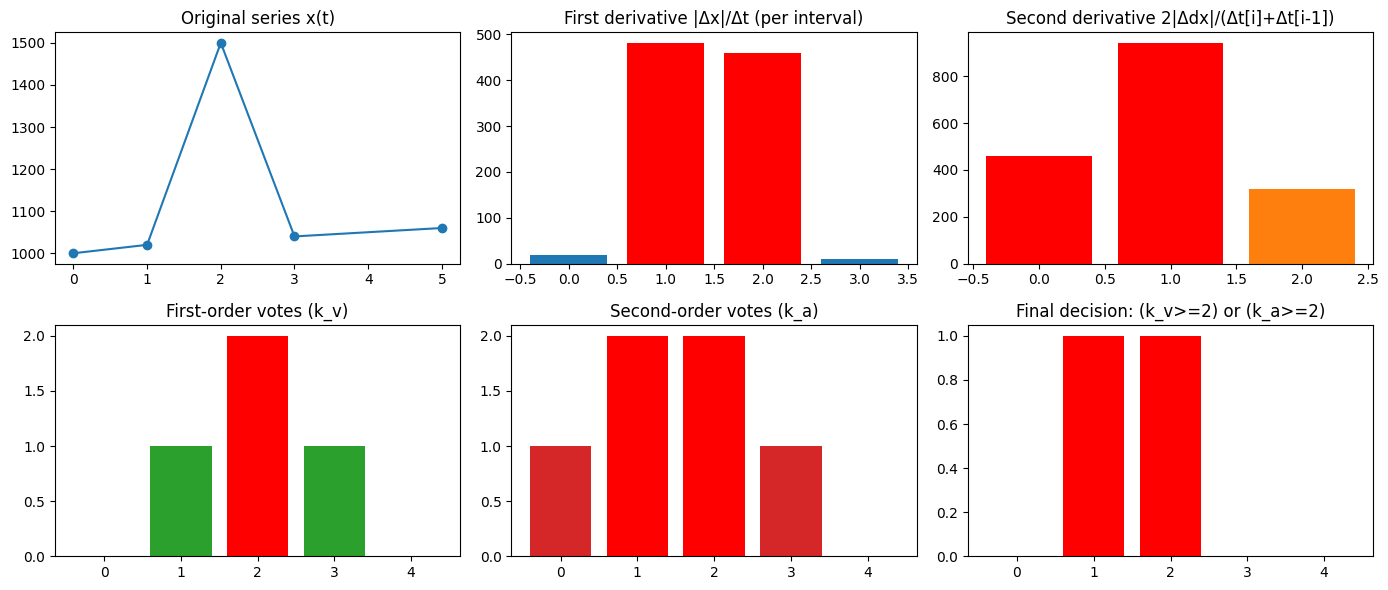

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 构造示例：不等间隔时间 + 一个突刺
t = np.array([0, 1, 2, 3, 5], dtype=float)  # 秒
x = np.array([1000, 1020, 1500, 1040, 1060], dtype=float)
dt = t[1:] - t[:-1]

# 一阶导
diff1val = x[1:] - x[:-1]
deriv1 = np.abs(diff1val) / dt

# 二阶导（中心在三点的中间）
diff2 = np.abs(diff1val[1:] - diff1val[:-1])
deriv2 = 2 * diff2 / (dt[1:] + dt[:-1])

# 设定简单阈值（示例用）
first, second = 200.0, 400.0
spike_v = deriv1 >= first
spike_a = deriv2 >= second

# 投票数组（与有效值同长度）
k_v = np.zeros_like(x)
k_a = np.zeros_like(x)

# 一阶投票：区间 (i-1,i) 影响端点 i-1 和 i
k_v[:-1] += spike_v
k_v[1:]  += spike_v

# 二阶投票：三点窗口影响 i-1, i, i+1（spike_a 对应的是 i 索引从 1 到 len(x)-2）
k_a[:-2] += spike_a  # i-1
k_a[1:-1] += spike_a # i
k_a[2:] += spike_a   # i+1

# 源码判定：分别计票、分别阈值
mask_v = k_v >= 2
mask_a = k_a >= 2
mask = np.logical_or(mask_v, mask_a)

print('t:', t)
print('x:', x)
print('dt:', dt)
print('deriv1:', deriv1)
print('deriv2:', deriv2)
print('k_v:', k_v)
print('k_a:', k_a)
print('mask_v (k_v>=2):', mask_v)
print('mask_a (k_a>=2):', mask_a)
print('final mask:', mask)

# 可视化（英文标题）
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
ax = axes[0,0]
ax.plot(t, x, '-o')
ax.set_title('Original series x(t)')

ax = axes[0,1]
ax.bar(np.arange(len(deriv1)), deriv1, color=['red' if v else 'C0' for v in spike_v])
ax.set_title('First derivative |Δx|/Δt (per interval)')

ax = axes[0,2]
ax.bar(np.arange(len(deriv2)), deriv2, color=['red' if v else 'C1' for v in spike_a])
ax.set_title('Second derivative 2|Δdx|/(Δt[i]+Δt[i-1])')

ax = axes[1,0]
ax.bar(np.arange(len(x)), k_v, color=['red' if m else 'C2' for m in mask_v])
ax.set_title('First-order votes (k_v)')

ax = axes[1,1]
ax.bar(np.arange(len(x)), k_a, color=['red' if m else 'C3' for m in mask_a])
ax.set_title('Second-order votes (k_a)')

ax = axes[1,2]
ax.bar(np.arange(len(x)), mask.astype(int), color=['red' if m else 'C4' for m in mask])
ax.set_title('Final decision: (k_v>=2) or (k_a>=2)')

plt.tight_layout()
plt.show()


## 索引映射示意（Index Mapping）

这一节用文字说明导数索引与投票落点的对应关系：
- 点索引：共有 n 个点，索引为 0..n-1。
- 一阶导（长度 n-1）：索引 j=0..n-2，对应区间 (j, j+1)，投票给这两个端点。
- 二阶导（长度 n-2）：索引 k=0..n-3，对应三点窗口中心在 k+1，投票给 [k, k+1, k+2]。
- 当前实现判定：分别计票、分别判定；(k_v>=2) 或 (k_a>=2) 即置 NaN。


In [9]:
# 显示 spike 与投票的索引映射（复用上文的 t, x, k_v, k_a, spike_v, spike_a）
import numpy as np

n = len(x)
print(f"点索引: 0..{n-1}")
print(f"一阶导索引(长度 {len(spike_v)}): 0..{len(spike_v)-1}")
print(f"二阶导索引(长度 {len(spike_a)}): 0..{len(spike_a)-1}")

print("一阶导触发 → 票数落点: (j -> [j, j+1])")
for j, s in enumerate(spike_v):
    if s:
        print(f"  spike_v[{j}] -> points [{j}, {j+1}]")

print("二阶导触发 → 票数落点: (k -> [k, k+1, k+2])")
for k, s in enumerate(spike_a):
    if s:
        print(f"  spike_a[{k}] -> points [{k}, {k+1}, {k+2}]")

print("累计票数：")
print("  k_v:", k_v)
print("  k_a:", k_a)
print("  mask_v (k_v>=2):", k_v >= 2)
print("  mask_a (k_a>=2):", k_a >= 2)
print("  final mask:", np.logical_or(k_v >= 2, k_a >= 2))


点索引: 0..4
一阶导索引(长度 4): 0..3
二阶导索引(长度 3): 0..2
一阶导触发 → 票数落点: (j -> [j, j+1])
  spike_v[1] -> points [1, 2]
  spike_v[2] -> points [2, 3]
二阶导触发 → 票数落点: (k -> [k, k+1, k+2])
  spike_a[0] -> points [0, 1, 2]
  spike_a[1] -> points [1, 2, 3]
累计票数：
  k_v: [0. 1. 2. 1. 0.]
  k_a: [1. 2. 2. 1. 0.]
  mask_v (k_v>=2): [False False  True False False]
  mask_a (k_a>=2): [False  True  True False False]
  final mask: [False  True  True False False]
